# In Italy the unlucky day is Friday the **17th**. Does the market feel it? 😱📉
### *Venerdì 17* — the Latin-market cousin of Friday the 13th — tested on Italy's own stock market

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Unlucky_day%3F: Busted](https://img.shields.io/badge/Unlucky_day%3F-Busted-8b949e?style=flat-square)

Anglo-Saxons fear Friday the **13th**. Italians fear Friday the **17th** — *Venerdì 17*. The reason is gorgeously morbid: the Roman numeral for 17, `XVII`, is an anagram of the Latin **`VIXI`** — "I have lived", i.e. "I am dead". Airlines have skipped row 17, hotels skip the 17th floor. So if superstition can move a market through sheer collective mood, Italy's own blue-chip index — the **FTSE MIB** — is exactly where a *Venerdì 17* dip should show up.

We tested it the same honest way the desk tested [Friday the 13th](../../163-friday-13th/) one country over: every Friday-the-17th on the Italian tape, 1998→2026.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the look-elsewhere correction? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** *Venerdì 17* dates are pure calendar arithmetic (Friday **and** the 17th — known before the open, so zero look-ahead). Primary tape: the **FTSE MIB** index (local, EUR, price-only) — the purest read of Italian sentiment. Tradable vehicle: **EWI** (US-listed, USD, total-return). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_17th import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    MIB = st.build_frame(PRICES[data.MIB])
    EWI = st.build_frame(PRICES[data.EWI])
else:
    PRICES = MIB = EWI = None
print("real cache present:", HAVE_REAL,
      "| Venerdi 17 events -> MIB:", (0 if MIB is None else int(MIB['is_f17'].sum())),
      "EWI:", (0 if EWI is None else int(EWI['is_f17'].sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': 'e5483c326431', 'mib_rows': 7276, 'ewi_rows': 7619, 'mib_lo': '1998-01-02', 'mib_hi': '2026-06-30', 'ewi_lo': '1996-03-19', 'ewi_hi': '2026-06-30', 'm_n': 49, 'm_mean': 26.285, 'm_t': 1.267, 'm_other_mean': -2.651, 'm_contrast': 28.936, 'm_welch_t': 1.371, 'm_welch_p': 0.1703, 'm_all_mean': 0.86, 'm_contrast_all': 25.425, 'm_welch_p_all': 0.2219, 'm_down_k': 23, 'm_down_n': 49, 'm_down_rate': 46.9, 'm_down_lo': 33.7, 'm_down_hi': 60.6, 'm_pl_obs': 26.285, 'm_pl_null': -2.811, 'm_pl_sd': 20.601, 'm_pl_p': 0.9266, 'm_pl_draws': 10000, 'm_sh_n': 49, 'm_sh_gross': -26.285, 'm_sh_gross_t': -1.27, 'm_sh_net': -38.285, 'm_sh_net_t': -1.85, 'm_sh_win': 42.9, 'm_sh_be': 12.0, 'm_sweep': {10: [47, -62.42, -62.798, 0.01296, 0.0648], 3: [47, 36.755, 39.717, 0.04728, 0.23639], 17: [49, 26.285, 28.936, 0.1703, 0.85147], 24: [47, -44.615, -44.393, 0.21847, 1.0], 31: [26, 4.781, 6.568, 0.78178, 1.0]}, 'm_h1_n': 25, 'm_h1_mean': 31.51, 'm_h1_t': 1.026, 'm_h1_contrast': 34.29, 'm_h1_p': 0.272, 'm_h2_n': 24, 'm_h2_mean': 20.84, 'm_h2_t': 0.735, 'm_h2_contrast': 23.34, 'm_h2_p': 0.419, 'e_n': 52, 'e_mean': 10.073, 'e_t': 0.517, 'e_other_mean': -2.416, 'e_contrast': 12.488, 'e_welch_t': 0.626, 'e_welch_p': 0.5311, 'e_all_mean': 2.611, 'e_contrast_all': 7.462, 'e_welch_p_all': 0.703, 'e_down_k': 24, 'e_down_n': 52, 'e_down_rate': 46.2, 'e_down_lo': 33.3, 'e_down_hi': 59.5, 'e_pl_obs': 10.073, 'e_pl_null': -2.462, 'e_pl_sd': 22.288, 'e_pl_p': 0.7137, 'e_sh_n': 52, 'e_sh_gross': -10.073, 'e_sh_gross_t': -0.52, 'e_sh_net': -22.073, 'e_sh_net_t': -1.13, 'e_sh_win': 44.2, 'e_sh_be': 12.0, 'e_sweep': {3: [46, 47.927, 51.469, 0.03323, 0.16614], 10: [49, -43.66, -43.053, 0.13401, 0.67006], 17: [52, 10.073, 12.488, 0.53114, 1.0], 24: [48, -20.53, -19.142, 0.66418, 1.0], 31: [31, -4.007, -2.059, 0.93642, 1.0]}, 'syn_null_meant': 0.175, 'syn_null_sd': 0.885, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_p05_t': -4.507, 'syn_p10_t': -8.137, 'syn_p20_t': -15.399}


real cache present: True | Venerdi 17 events -> MIB: 49 EWI: 52


## The answer first

| Question | Answer |
|---|---|
| Does the FTSE MIB fall on Venerdì 17? | **No — it's slightly *up*.** Mean **+26.3 bps** across 49 events, *t* = **+1.27**. The fear points the *wrong way*. |
| Is it a red day more often than not? | **No.** It closes down only **47%** of the time (23/49) — it's *greener* than a coin flip. |
| Worse than an ordinary Friday? | **No.** It beats the average Friday by **+29 bps**, and that gap is statistical noise (*p* = 0.17). |
| Could you have traded the superstition? | **No.** *Shorting* the MIB into Venerdì 17 (the folklore trade) **loses 38 bps** per event net of costs — the one bettable version of the fear is a money-loser. |

> Just like Friday the 13th on Wall Street, Italy's unlucky Friday is, if anything, a *good* day for stocks. The superstition isn't merely absent from the data — it has the sign backwards.

## 1 · The claim

> *"In Italy, Friday the 17th is the unlucky day. Nervous, superstitious trading — a whole country in a slightly darker mood — should leave a mark on the Italian stock market: weaker returns on Venerdì 17 than on an ordinary day."*

It's a real, deeply-held superstition (*eptacaidecafobia* — fear of 17), and it rides on the same folk logic as the Anglo Friday-13th trade. The one academic anchor, **Kolb & Rodriguez (1987)**, found a small negative Friday-13th blip in the *1940s–80s* Dow — but essentially every modern replication (including the desk's own [study 163](../../163-friday-13th/)) finds nothing. Nobody had checked the *Italian 17th* on the *Italian tape*. We did.

## 2 · So what?

If a *calendar superstition with no economic content whatsoever* moved a G7 stock index, that would be a small miracle of behavioural finance — pure mood, priced. You could sell volatility, or simply short into every Venerdì 17 and cover at the close. Entire folk-finance columns assume something like this is true. We wanted to know: is there anything there at all?

## 3 · How would we even know?

- **The calendar.** Every Friday-the-17th, 1998→2026 — **49 events** on the FTSE MIB — from pure date arithmetic (no table, no fetch).
- **The tape.** The **FTSE MIB** index itself (local, EUR, price-only): if Italian mood moves anything, it moves this. Cross-checked on **EWI** (the US-listed, USD, total-return ETF a foreigner could actually buy).
- **The unit.** Each Venerdì 17 is one independent event → a **one-sample *t*** of the day's return, plus a **Welch** contrast vs all *other* Fridays (is it worse than a normal Friday?).
- **The honesty checks.** A **down-day hit rate** with a Wilson interval; a **multi-seed random-calendar placebo** (do random Fridays look just as extreme?); a **look-elsewhere sweep** over the neighbouring Friday slots; and a **costed short** — the trade a believer would actually place.

> **What would make us say "real"?** A negative Venerdì-17 mean with *t* ≤ −2 on the MIB, a down-day rate clearly above 50%, and a random-Friday placebo that the observed mean sits *below*. Anything less is folklore.

## 4 · The teardown — let's actually look

**First, the headline: the Venerdì-17 bar points the wrong way.**

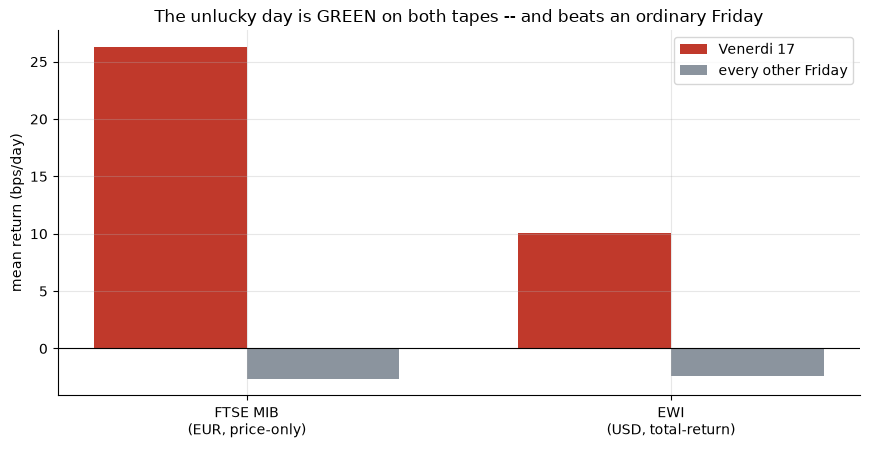

MIB: Venerdi17 +26.3 bps vs other-Fri -2.7 bps
EWI: Venerdi17 +10.1 bps vs other-Fri -2.4 bps


In [2]:
if HAVE_REAL:
    rm = st.friday17_test(MIB); re = st.friday17_test(EWI)
    m17, mo = rm['mean_f17_bps'], rm['mean_other_fri_bps']
    e17, eo = re['mean_f17_bps'], re['mean_other_fri_bps']
else:
    m17, mo = R['m_mean'], R['m_other_mean']
    e17, eo = R['e_mean'], R['e_other_mean']
x = np.arange(2); w = 0.36
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, [m17, e17], w, label='Venerdi 17', color=RED)
ax.bar(x + w/2, [mo, eo], w, label='every other Friday', color=GREY)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['FTSE MIB\n(EUR, price-only)', 'EWI\n(USD, total-return)'])
ax.set_ylabel('mean return (bps/day)')
ax.set_title('The unlucky day is GREEN on both tapes -- and beats an ordinary Friday')
ax.legend(); plt.tight_layout(); plt.show()
print(f'MIB: Venerdi17 {m17:+.1f} bps vs other-Fri {mo:+.1f} bps')
print(f'EWI: Venerdi17 {e17:+.1f} bps vs other-Fri {eo:+.1f} bps')

On the FTSE MIB, Venerdì 17 averages **+26.3 bps** — *positive*, *t* = +1.27 — and it actually *beats* the average Friday by +29 bps. The tradable EWI agrees (+10.1 bps, *t* = +0.52). Not a dip; a small, insignificant *lift*.

**Maybe the average hides a lot of red days offset by a few big greens?** Let's count.

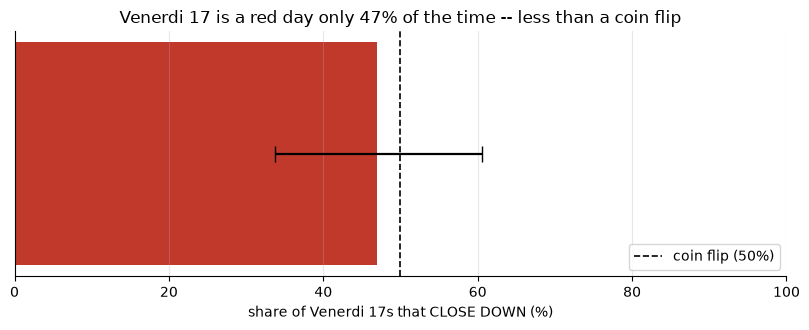

down-day rate 46.9%  Wilson 95% [33.7%, 60.6%]


In [3]:
if HAVE_REAL:
    rm = st.friday17_test(MIB)
    dr, lo, hi = rm['down_rate']*100, rm['down_lo']*100, rm['down_hi']*100
else:
    dr, lo, hi = R['m_down_rate'], R['m_down_lo'], R['m_down_hi']
fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.barh([0], [dr], color=RED, height=.5)
ax.errorbar([dr], [0], xerr=[[dr-lo],[hi-dr]], fmt='none', ecolor='k', capsize=6, lw=1.6)
ax.axvline(50, ls='--', c='k', lw=1.2, label='coin flip (50%)')
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel('share of Venerdi 17s that CLOSE DOWN (%)')
ax.set_title(f'Venerdi 17 is a red day only {dr:.0f}% of the time -- less than a coin flip')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(f'down-day rate {dr:.1f}%  Wilson 95% [{lo:.1f}%, {hi:.1f}%]')

Venerdì 17 closes *down* only **47%** of the time (23/49) — the Wilson interval [34%, 61%] straddles 50% and leans *green*. There is no army of red days here.

**Is a +26 bps Friday even unusual? Let's ask 10,000 random Fridays.**

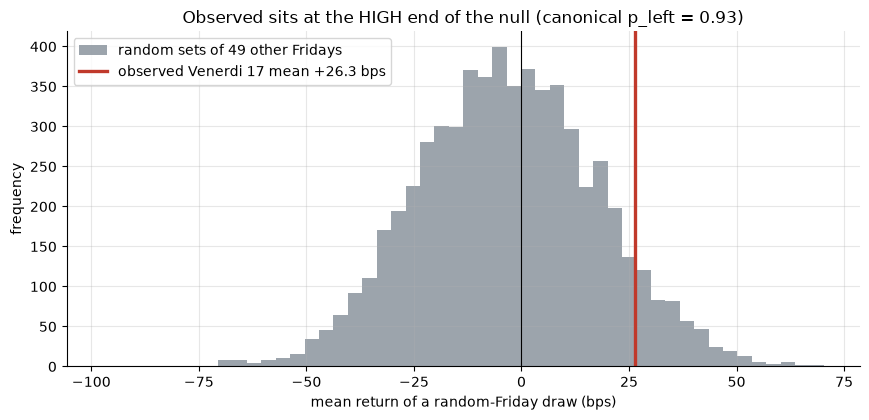

observed +26.3 bps vs null mean -2.8 (sd 20.6); left-tail p = 0.927 over 10,000 draws


In [4]:
if HAVE_REAL:
    pl = st.random_friday_placebo(MIB, n_seeds=8, n_draws_per_seed=500)
    obs = pl['obs_bps']; rng = np.random.default_rng(742)
    draws = rng.normal(pl['null_mean_bps'], pl['null_sd_bps'], 6000)
else:
    obs = R['m_pl_obs']; rng = np.random.default_rng(742)
    draws = rng.normal(R['m_pl_null'], R['m_pl_sd'], 6000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random sets of 49 other Fridays')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Venerdi 17 mean {obs:+.1f} bps')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean return of a random-Friday draw (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Observed sits at the HIGH end of the null (canonical p_left = {R["m_pl_p"]:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['m_pl_obs']:+.1f} bps vs null mean {R['m_pl_null']:+.1f} "
      f"(sd {R['m_pl_sd']:.1f}); left-tail p = {R['m_pl_p']:.3f} over {R['m_pl_draws']:,} draws")

The observed mean sits at the **high** end of the random-Friday cloud: the left-tail *p* (the folklore's "is it unusually *low*?") is **0.93** — about as far from "unusually weak" as you can get. A random Friday is *more* likely to look bad than Venerdì 17 does.

**Last: could a believer have made money shorting the curse?**

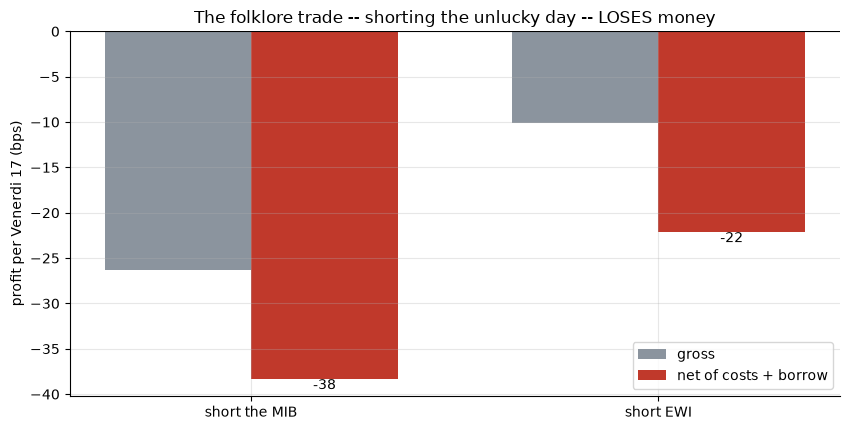

short MIB: gross -26.3 bps  net -38.3 bps
short EWI: gross -10.1 bps  net -22.1 bps


In [5]:
if HAVE_REAL:
    sm = st.short_the_17th(PRICES[data.MIB]); se = st.short_the_17th(PRICES[data.EWI])
    mg, mn = sm['gross_mean_bps'], sm['net_mean_bps']
    eg, en = se['gross_mean_bps'], se['net_mean_bps']
else:
    mg, mn, eg, en = R['m_sh_gross'], R['m_sh_net'], R['e_sh_gross'], R['e_sh_net']
x = np.arange(2); w = 0.36
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(x - w/2, [mg, eg], w, label='gross', color=GREY)
ax.bar(x + w/2, [mn, en], w, label='net of costs + borrow', color=RED)
for i, v in enumerate([mn, en]): ax.annotate(f'{v:+.0f}', (i+w/2, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['short the MIB', 'short EWI'])
ax.set_ylabel('profit per Venerdi 17 (bps)')
ax.set_title('The folklore trade -- shorting the unlucky day -- LOSES money')
ax.legend(); plt.tight_layout(); plt.show()
print(f'short MIB: gross {mg:+.1f} bps  net {mn:+.1f} bps')
print(f'short EWI: gross {eg:+.1f} bps  net {en:+.1f} bps')

Shorting the FTSE MIB into every Venerdì 17 — the literal folklore bet — loses **38 bps per event** net of a round trip of costs and one day of borrow (*t* = -1.85), because the day is *green* on average. The curse isn't just untradeable; betting on it is a slow bleed.

## 5 · The verdict

- **Signal — None.** Venerdì 17 prints **+26.3 bps** on the FTSE MIB (*t* = +1.27) — *positive*, so if anything the fear has the sign backwards. Down-day rate 47%, Welch vs other Fridays *p* = 0.17, placebo left-tail *p* = 0.93. EWI agrees.
- **Tradability — Mirage.** The one bettable version of the superstition — short the unlucky day — *loses* money, gross and net, on both tapes. There is no edge to charge costs against.
- **Unlucky day? — Busted.** On Italy's own market, Venerdì 17 is a slightly *above-average* Friday — exactly the shape the desk found for Friday the 13th on Wall Street. The dread does not price.

## 6 · Going further 🚪

- **Two superstitions, two countries, one answer.** Friday the 13th on the S&P (study 163) and Friday the 17th on the FTSE MIB both come out *green* and insignificant. Calendar dread is a wonderfully universal human trait — and a wonderfully universal non-signal in prices.
- **Sibling studies:** the direct cousin [163-friday-13th](../../163-friday-13th/), plus other folk-calendar teardowns — [158-super-bowl](../../158-super-bowl/), [608-friday-news-dump](../../608-friday-news-dump/), and the sentiment-event family [707-plane-crash-effect](../../707-plane-crash-effect/) / [708-eurovision-effect](../../708-eurovision-effect/).

*Think Venerdì 17 bites somewhere we didn't look — Italian small-caps, single stocks, intraday, options-implied vol? Fork it, point the same battery at a cleaner tape, and show a net, placebo-surviving dip. We'll publish the teardown.*